In [81]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import shutil
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import VGG16

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [3]:
train_dir = '/content/drive/MyDrive/AI ML Year 3 /FinalCoursework/Traffic_Sign-20260506T093825Z-3-001/Traffic_Sign/Train'

test_dir = '/content/drive/MyDrive/AI ML Year 3 /FinalCoursework/Traffic_Sign-20260506T093825Z-3-001/Traffic_Sign/Test'

#Part A: Data Understanding, Analysis, Visualization and Cleaning

Check Class Distribution

In [4]:
class_count = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        class_count[class_name] = len(os.listdir(class_path))

print("Class distribution:")
print(class_count)

print("Total training images:", sum(class_count.values()))

Class distribution:
{'OverSpeed': 5260, 'Caution': 2429, 'No Passing': 5369, 'Instructions': 2848}
Total training images: 15906


Plot Class Distribution Graph

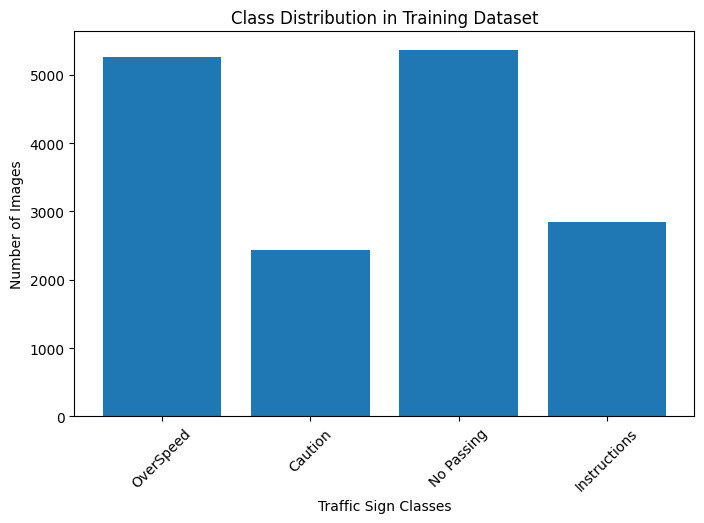

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(class_count.keys(), class_count.values())
plt.title("Class Distribution in Training Dataset")
plt.xlabel("Traffic Sign Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

Visualize Sample Images

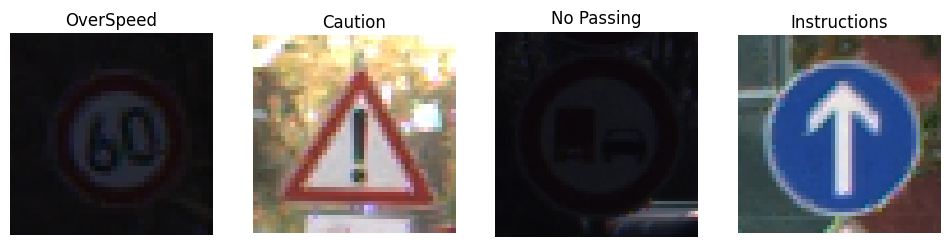

In [6]:
plt.figure(figsize=(12, 5))

for i, class_name in enumerate(class_count.keys()):
    class_path = os.path.join(train_dir, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path)

    plt.subplot(1, len(class_count), i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.show()

Detect Corrupted Images

In [7]:
def check_corrupted_images(directory):
    corrupted_files = []

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):
            for filename in os.listdir(class_path):
                file_path = os.path.join(class_path, filename)

                try:
                    img = Image.open(file_path)
                    img.verify()

                except Exception:
                    corrupted_files.append(file_path)

    return corrupted_files


corrupted_train = check_corrupted_images(train_dir)
corrupted_test = check_corrupted_images(test_dir)

print("Corrupted training images:", len(corrupted_train))
print("Corrupted testing images:", len(corrupted_test))

for file in corrupted_train:
    print(file)

Corrupted training images: 28
Corrupted testing images: 0
/content/drive/MyDrive/AI ML Year 3 /FinalCoursework/Traffic_Sign-20260506T093825Z-3-001/Traffic_Sign/Train/OverSpeed/00004_00005_00020.png
/content/drive/MyDrive/AI ML Year 3 /FinalCoursework/Traffic_Sign-20260506T093825Z-3-001/Traffic_Sign/Train/OverSpeed/00005_00035_00027.png
/content/drive/MyDrive/AI ML Year 3 /FinalCoursework/Traffic_Sign-20260506T093825Z-3-001/Traffic_Sign/Train/OverSpeed/00005_00009_00027.png
/content/drive/MyDrive/AI ML Year 3 /FinalCoursework/Traffic_Sign-20260506T093825Z-3-001/Traffic_Sign/Train/OverSpeed/00005_00058_00027.png
/content/drive/MyDrive/AI ML Year 3 /FinalCoursework/Traffic_Sign-20260506T093825Z-3-001/Traffic_Sign/Train/OverSpeed/00004_00057_00006.png
/content/drive/MyDrive/AI ML Year 3 /FinalCoursework/Traffic_Sign-20260506T093825Z-3-001/Traffic_Sign/Train/OverSpeed/00004_00058_00025.png
/content/drive/MyDrive/AI ML Year 3 /FinalCoursework/Traffic_Sign-20260506T093825Z-3-001/Traffic_Sign/

Create Clean Dataset Without Deleting Original Files

In [8]:
clean_train_dir = '/content/clean_Traffic_Sign_Train'

os.makedirs(clean_train_dir, exist_ok=True)

def create_clean_dataset(original_dir, clean_dir):
    corrupted_files = []
    valid_count = 0

    for class_name in os.listdir(original_dir):
        class_path = os.path.join(original_dir, class_name)

        if os.path.isdir(class_path):
            clean_class_path = os.path.join(clean_dir, class_name)
            os.makedirs(clean_class_path, exist_ok=True)

            for filename in os.listdir(class_path):
                file_path = os.path.join(class_path, filename)

                try:
                    img = Image.open(file_path)
                    img.verify()

                    shutil.copy(file_path, os.path.join(clean_class_path, filename))
                    valid_count += 1

                except Exception:
                    corrupted_files.append(file_path)

    return corrupted_files, valid_count


corrupted_train_files, valid_train_count = create_clean_dataset(train_dir, clean_train_dir)

print("Clean dataset created at:", clean_train_dir)
print("Valid images copied:", valid_train_count)
print("Corrupted images skipped:", len(corrupted_train_files))

Clean dataset created at: /content/clean_Traffic_Sign_Train
Valid images copied: 15878
Corrupted images skipped: 28


Data Preprocessing and Augmentation

In [35]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

Load Train and Test Data

In [36]:
train_generator = train_datagen.flow_from_directory(
    clean_train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 15878 images belonging to 4 classes.
Found 4 images belonging to 4 classes.


Check Batch Shape

In [37]:
sample_images, sample_labels = next(train_generator)

print("Image Batch Shape:", sample_images.shape)
print("Label Batch Shape:", sample_labels.shape)

Image Batch Shape: (32, 64, 64, 3)
Label Batch Shape: (32, 4)


Visualize Augmented Images

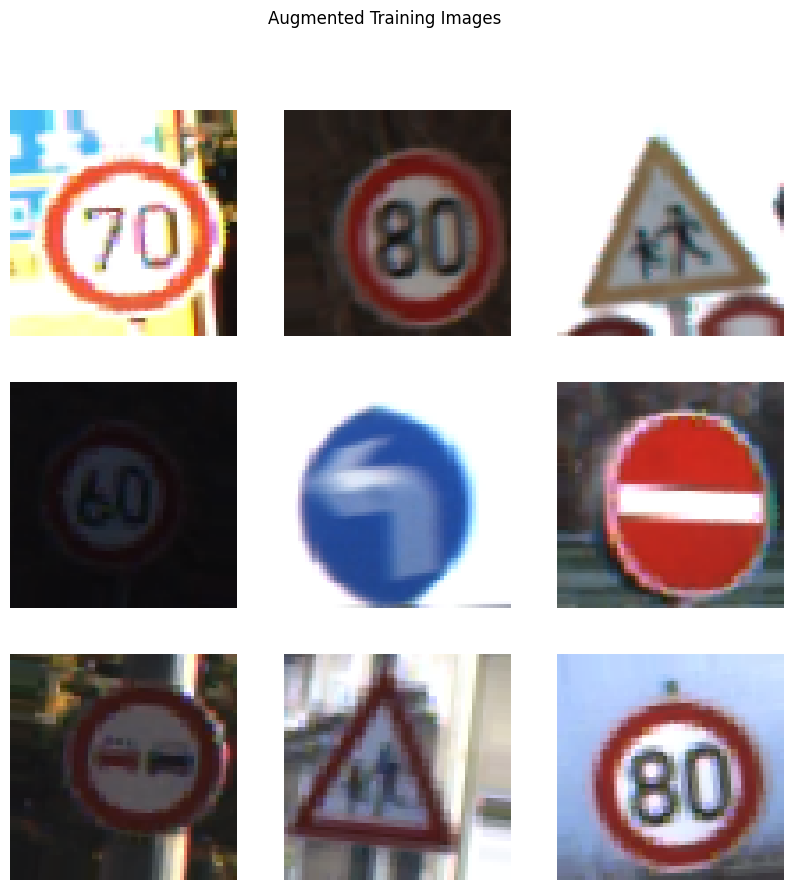

In [38]:
sample_images, sample_labels = next(train_generator)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i])
    plt.axis('off')

plt.suptitle("Augmented Training Images")
plt.show()

Show Class Indices

In [39]:
print("Class Indices:")
print(train_generator.class_indices)

class_labels = list(train_generator.class_indices.keys())
print("Class Labels:", class_labels)

Class Indices:
{'Caution': 0, 'Instructions': 1, 'No Passing': 2, 'OverSpeed': 3}
Class Labels: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']


#Baseline CNN Model

Define Baseline CNN

In [40]:
baseline_model = Sequential()

baseline_model.add(Input(shape=(64, 64, 3)))

baseline_model.add(Conv2D(32, (3, 3), activation='relu'))
baseline_model.add(MaxPooling2D(pool_size=(2, 2)))

baseline_model.add(Conv2D(64, (3, 3), activation='relu'))
baseline_model.add(MaxPooling2D(pool_size=(2, 2)))

baseline_model.add(Conv2D(128, (3, 3), activation='relu'))
baseline_model.add(MaxPooling2D(pool_size=(2, 2)))

baseline_model.add(Flatten())

baseline_model.add(Dense(256, activation='relu'))
baseline_model.add(Dense(128, activation='relu'))
baseline_model.add(Dense(64, activation='relu'))

baseline_model.add(Dense(4, activation='softmax'))

Compile Baseline Model

In [41]:
baseline_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Baseline Model Summary

In [42]:
baseline_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,564 (5.01 MB)

 Trainable params: 1,314,564 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

Train Baseline Model

In [43]:
start_time = time.time()

history_baseline = baseline_model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator
)

baseline_training_time = time.time() - start_time

print("Baseline Training Time:", baseline_training_time, "seconds")

Epoch 1/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 35s 62ms/step - accuracy: 0.8766 - loss: 0.3147 - val_accuracy: 0.7500 - val_loss: 0.2113
Epoch 2/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.9832 - loss: 0.0514 - val_accuracy: 0.7500 - val_loss: 0.2624
Epoch 3/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.9908 - loss: 0.0325 - val_accuracy: 0.7500 - val_loss: 0.2343
Epoch 4/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.9944 - loss: 0.0183 - val_accuracy: 1.0000 - val_loss: 0.0060
Epoch 5/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.9955 - loss: 0.0155 - val_accuracy: 1.0000 - val_loss: 0.0135
Epoch 6/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.9962 - loss: 0.0131 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 7/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.9936 - loss: 0.0218 - val_accuracy: 1.0000 - val_loss: 0.0223
Epoch 8/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.9958 - loss: 0.0153 - 





Baseline Accuracy Graph

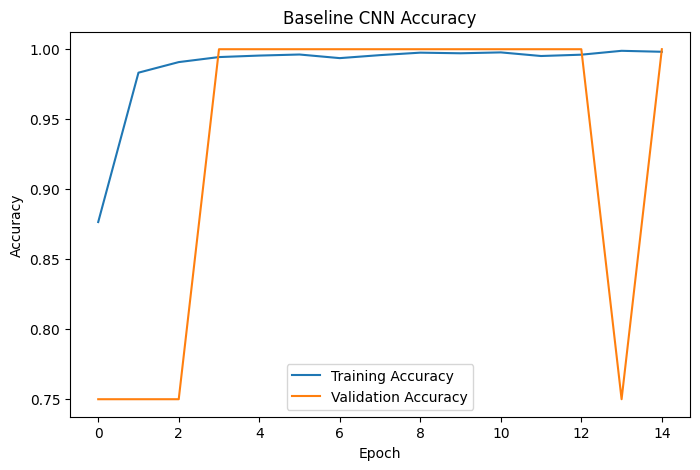

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.title('Baseline CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Baseline Loss Graph

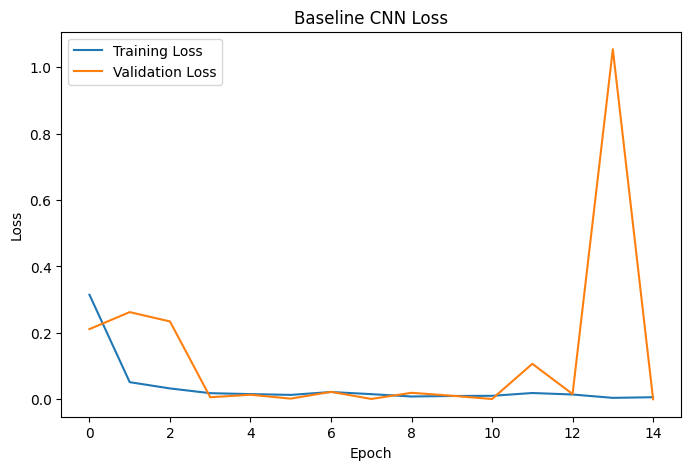

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title('Baseline CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Evaluate Baseline Model

In [46]:
baseline_loss, baseline_accuracy = baseline_model.evaluate(test_generator)

print("Baseline Test Loss:", baseline_loss)
print("Baseline Test Accuracy:", baseline_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 4.3448e-05
Baseline Test Loss: 4.344802437117323e-05
Baseline Test Accuracy: 1.0


Baseline Precision, Recall, F1-score and Confusion Matrix

In [48]:
test_generator.reset()

baseline_predictions = baseline_model.predict(test_generator)
baseline_pred_classes = np.argmax(baseline_predictions, axis=1)

true_classes = test_generator.classes

baseline_precision = precision_score(true_classes, baseline_pred_classes, average='weighted', zero_division=0)
baseline_recall = recall_score(true_classes, baseline_pred_classes, average='weighted', zero_division=0)
baseline_f1 = f1_score(true_classes, baseline_pred_classes, average='weighted', zero_division=0)

print("Baseline Precision:", baseline_precision)
print("Baseline Recall:", baseline_recall)
print("Baseline F1-score:", baseline_f1)

print("\nBaseline Classification Report:")
print(classification_report(true_classes, baseline_pred_classes, target_names=class_labels, zero_division=0))

baseline_cm = confusion_matrix(true_classes, baseline_pred_classes)

print("Baseline Confusion Matrix:")
print(baseline_cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Baseline Precision: 1.0
Baseline Recall: 1.0
Baseline F1-score: 1.0

Baseline Classification Report:
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00         1
Instructions       1.00      1.00      1.00         1
  No Passing       1.00      1.00      1.00         1
   OverSpeed       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

Baseline Confusion Matrix:
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]


Baseline Confusion Matrix Graph

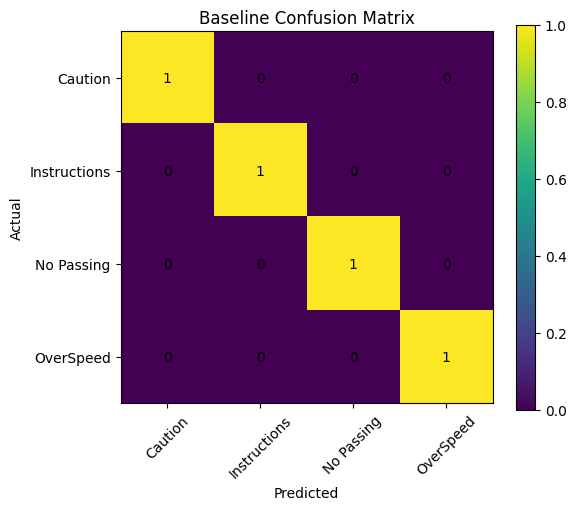

In [49]:
plt.figure(figsize=(6, 5))
plt.imshow(baseline_cm)
plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(np.arange(len(class_labels)), class_labels, rotation=45)
plt.yticks(np.arange(len(class_labels)), class_labels)

for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        plt.text(j, i, baseline_cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

Baseline Sample Prediction Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step


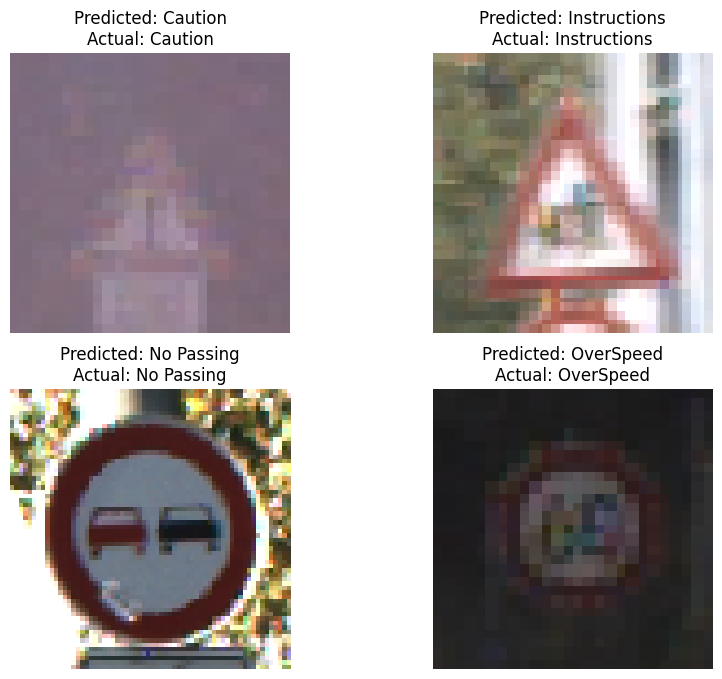

In [50]:
test_generator.reset()

images, labels = next(test_generator)

predictions = baseline_model.predict(images)
predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(labels, axis=1)

plt.figure(figsize=(10, 8))

for i in range(len(images)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i])
    plt.title("Predicted: " + class_labels[predicted_classes[i]] +
              "\nActual: " + class_labels[actual_classes[i]])
    plt.axis('off')

plt.show()

#Deeper CNN with Regularization

Define Deeper CNN Model

In [51]:
deeper_model = Sequential()

deeper_model.add(Input(shape=(64, 64, 3)))

deeper_model.add(Conv2D(64, (3, 3), activation='relu'))
deeper_model.add(BatchNormalization())
deeper_model.add(MaxPooling2D(pool_size=(2, 2)))

deeper_model.add(Conv2D(128, (3, 3), activation='relu'))
deeper_model.add(BatchNormalization())
deeper_model.add(MaxPooling2D(pool_size=(2, 2)))

deeper_model.add(Conv2D(256, (3, 3), activation='relu'))
deeper_model.add(BatchNormalization())
deeper_model.add(MaxPooling2D(pool_size=(2, 2)))

deeper_model.add(Conv2D(256, (3, 3), activation='relu'))
deeper_model.add(BatchNormalization())

deeper_model.add(Flatten())

deeper_model.add(Dense(256, activation='relu'))
deeper_model.add(Dropout(0.5))

deeper_model.add(Dense(128, activation='relu'))
deeper_model.add(Dropout(0.3))

deeper_model.add(Dense(64, activation='relu'))

deeper_model.add(Dense(4, activation='softmax'))

Compile Deeper Model with Adam

In [52]:
deeper_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Deeper Model Summary

In [53]:
deeper_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 62, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 29, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 29, 29, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,053,956 (7.84 MB)

 Trainable params: 2,052,548 (7.83 MB)

 Non-trainable params: 1,408 (5.50 KB)

Train Deeper Model

In [54]:
start_time = time.time()

history_deeper = deeper_model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator
)

deeper_training_time = time.time() - start_time

print("Deeper Model Training Time:", deeper_training_time, "seconds")

Epoch 1/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.8536 - loss: 0.4340 - val_accuracy: 0.7500 - val_loss: 0.5017
Epoch 2/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.9815 - loss: 0.0587 - val_accuracy: 1.0000 - val_loss: 0.0696
Epoch 3/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.9853 - loss: 0.0430 - val_accuracy: 0.7500 - val_loss: 1.2708
Epoch 4/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.9923 - loss: 0.0302 - val_accuracy: 1.0000 - val_loss: 0.1497
Epoch 5/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.9902 - loss: 0.0341 - val_accuracy: 0.7500 - val_loss: 0.2721
Epoch 6/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.9925 - loss: 0.0259 - val_accuracy: 0.5000 - val_loss: 0.9697
Epoch 7/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.9963 - loss: 0.0146 - val_accuracy: 0.7500 - val_loss: 0.3655
Epoch 8/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.9943 - loss: 0.0219 - 

Deeper Accuracy Graph

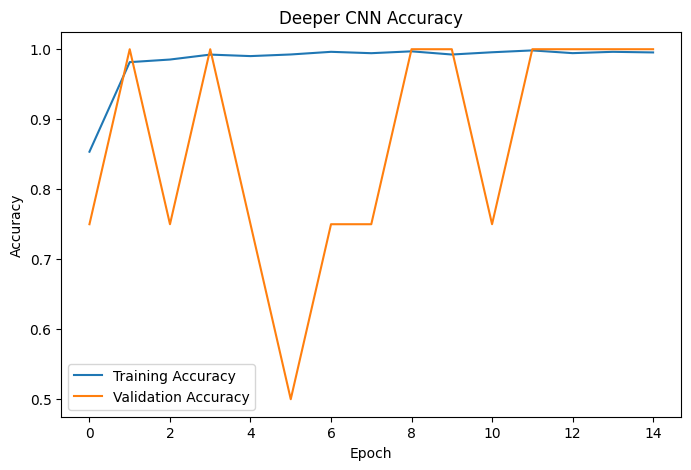

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(history_deeper.history['accuracy'], label='Training Accuracy')
plt.plot(history_deeper.history['val_accuracy'], label='Validation Accuracy')
plt.title('Deeper CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Deeper Loss Graph

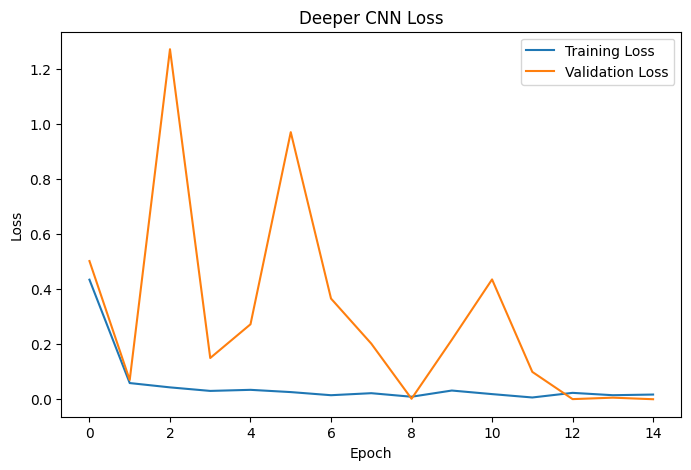

In [57]:
plt.figure(figsize=(8, 5))
plt.plot(history_deeper.history['loss'], label='Training Loss')
plt.plot(history_deeper.history['val_loss'], label='Validation Loss')
plt.title('Deeper CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Evaluate Deeper Model

In [58]:
deeper_loss, deeper_accuracy = deeper_model.evaluate(test_generator)

print("Deeper Test Loss:", deeper_loss)
print("Deeper Test Accuracy:", deeper_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 1.7702e-05
Deeper Test Loss: 1.77021101990249e-05
Deeper Test Accuracy: 1.0


Deeper Precision, Recall, F1-score and Confusion Matrix

In [59]:
test_generator.reset()

deeper_predictions = deeper_model.predict(test_generator)
deeper_pred_classes = np.argmax(deeper_predictions, axis=1)

deeper_precision = precision_score(true_classes, deeper_pred_classes, average='weighted', zero_division=0)
deeper_recall = recall_score(true_classes, deeper_pred_classes, average='weighted', zero_division=0)
deeper_f1 = f1_score(true_classes, deeper_pred_classes, average='weighted', zero_division=0)

print("Deeper Precision:", deeper_precision)
print("Deeper Recall:", deeper_recall)
print("Deeper F1-score:", deeper_f1)

print("\nDeeper Classification Report:")
print(classification_report(true_classes, deeper_pred_classes, target_names=class_labels, zero_division=0))

deeper_cm = confusion_matrix(true_classes, deeper_pred_classes)

print("Deeper Confusion Matrix:")
print(deeper_cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
Deeper Precision: 1.0
Deeper Recall: 1.0
Deeper F1-score: 1.0

Deeper Classification Report:
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00         1
Instructions       1.00      1.00      1.00         1
  No Passing       1.00      1.00      1.00         1
   OverSpeed       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

Deeper Confusion Matrix:
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]


Deeper Confusion Matrix Graph

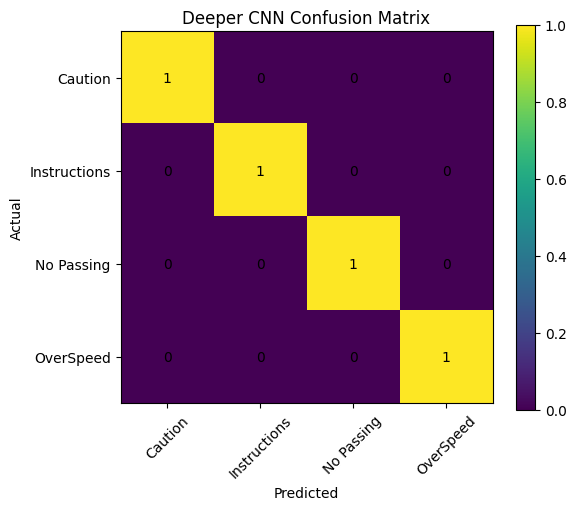

In [60]:
plt.figure(figsize=(6, 5))
plt.imshow(deeper_cm)
plt.title("Deeper CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(np.arange(len(class_labels)), class_labels, rotation=45)
plt.yticks(np.arange(len(class_labels)), class_labels)

for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        plt.text(j, i, deeper_cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

Deeper Model Prediction Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 977ms/step


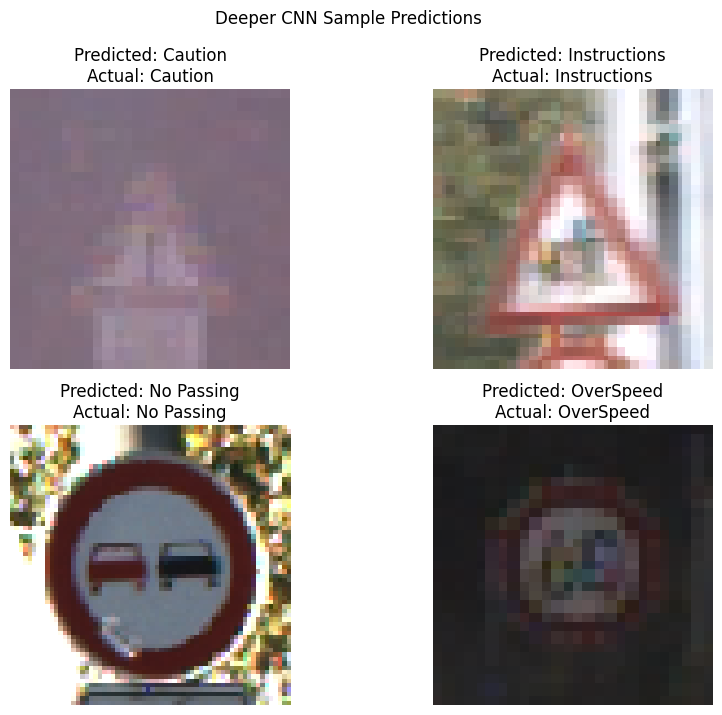

In [95]:
test_generator.reset()

images, labels = next(test_generator)

predictions = deeper_model.predict(images)
predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(labels, axis=1)

plt.figure(figsize=(10, 8))

for i in range(len(images)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i])
    plt.title("Predicted: " + class_labels[predicted_classes[i]] +
              "\nActual: " + class_labels[actual_classes[i]])
    plt.axis('off')

plt.suptitle("Deeper CNN Sample Predictions")
plt.show()

#Optimizer Analysis: Adam vs SGD

Function to Build Deeper Model

In [61]:
def build_deeper_model():
    model = Sequential()

    model.add(Input(shape=(64, 64, 3)))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(256, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(256, (3, 3), activation='relu'))
    model.add(BatchNormalization())

    model.add(Flatten())

    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(64, activation='relu'))

    model.add(Dense(4, activation='softmax'))

    return model

#Train Deeper model with SDG

In [62]:
deeper_model_sgd = build_deeper_model()

deeper_model_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_sgd = deeper_model_sgd.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator
)

sgd_training_time = time.time() - start_time

sgd_loss, sgd_accuracy = deeper_model_sgd.evaluate(test_generator)

print("SGD Test Loss:", sgd_loss)
print("SGD Test Accuracy:", sgd_accuracy)
print("SGD Training Time:", sgd_training_time)

Epoch 1/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 56s 99ms/step - accuracy: 0.8067 - loss: 0.5033 - val_accuracy: 0.7500 - val_loss: 0.4603
Epoch 2/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.9590 - loss: 0.1156 - val_accuracy: 0.7500 - val_loss: 0.3081
Epoch 3/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 34s 69ms/step - accuracy: 0.9758 - loss: 0.0695 - val_accuracy: 1.0000 - val_loss: 0.0094
Epoch 4/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.9859 - loss: 0.0438 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 5/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.9883 - loss: 0.0316 - val_accuracy: 1.0000 - val_loss: 0.0789
Epoch 6/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.9939 - loss: 0.0196 - val_accuracy: 1.0000 - val_loss: 4.0658e-04
Epoch 7/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.9936 - loss: 0.0226 - val_accuracy: 1.0000 - val_loss: 0.1349
Epoch 8/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.9950 - loss: 0.015

SGD Precision, Recall, F1-score

In [66]:
test_generator.reset()

sgd_predictions = deeper_model_sgd.predict(test_generator)
sgd_pred_classes = np.argmax(sgd_predictions, axis=1)

sgd_precision = precision_score(true_classes, sgd_pred_classes, average='weighted', zero_division=0)
sgd_recall = recall_score(true_classes, sgd_pred_classes, average='weighted', zero_division=0)
sgd_f1 = f1_score(true_classes, sgd_pred_classes, average='weighted', zero_division=0)

print("SGD Precision:", sgd_precision)
print("SGD Recall:", sgd_recall)
print("SGD F1-score:", sgd_f1)

print(classification_report(true_classes, sgd_pred_classes, target_names=class_labels, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
SGD Precision: 1.0
SGD Recall: 1.0
SGD F1-score: 1.0
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00         1
Instructions       1.00      1.00      1.00         1
  No Passing       1.00      1.00      1.00         1
   OverSpeed       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



SGD Confusion Matrix

SGD Confusion Matrix:
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]


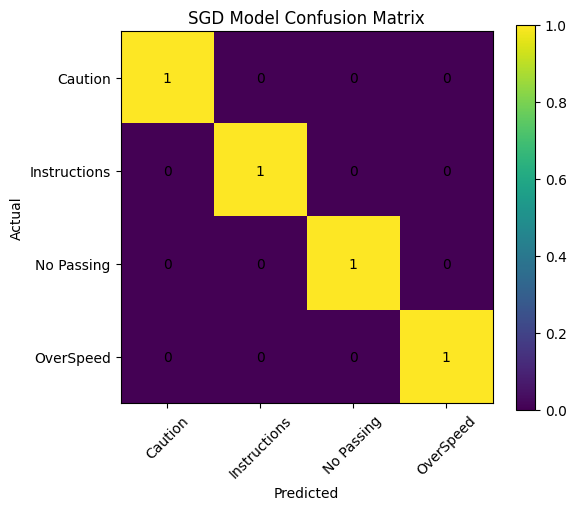

In [92]:
sgd_cm = confusion_matrix(true_classes, sgd_pred_classes)

print("SGD Confusion Matrix:")
print(sgd_cm)

plt.figure(figsize=(6, 5))
plt.imshow(sgd_cm)
plt.title("SGD Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(np.arange(len(class_labels)), class_labels, rotation=45)
plt.yticks(np.arange(len(class_labels)), class_labels)

for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        plt.text(j, i, sgd_cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

Adam vs SGD Accuracy Graph

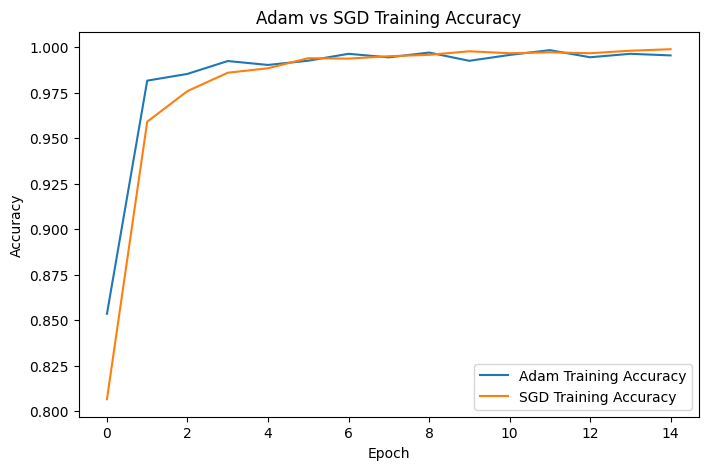

In [67]:
plt.figure(figsize=(8, 5))
plt.plot(history_deeper.history['accuracy'], label='Adam Training Accuracy')
plt.plot(history_sgd.history['accuracy'], label='SGD Training Accuracy')
plt.title('Adam vs SGD Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Adam vs SGD Loss Graph

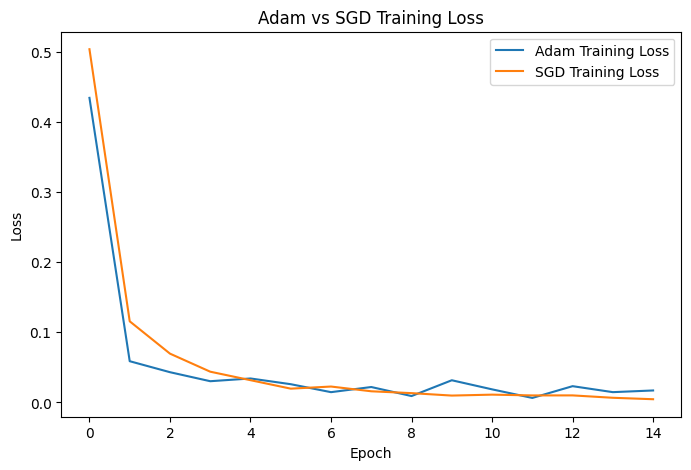

In [68]:
plt.figure(figsize=(8, 5))
plt.plot(history_deeper.history['loss'], label='Adam Training Loss')
plt.plot(history_sgd.history['loss'], label='SGD Training Loss')
plt.title('Adam vs SGD Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#Ablation Study: Remove Dropout

Define Ablation Model Without Dropout

In [69]:
ablation_model = Sequential()

ablation_model.add(Input(shape=(64, 64, 3)))

ablation_model.add(Conv2D(64, (3, 3), activation='relu'))
ablation_model.add(BatchNormalization())
ablation_model.add(MaxPooling2D(pool_size=(2, 2)))

ablation_model.add(Conv2D(128, (3, 3), activation='relu'))
ablation_model.add(BatchNormalization())
ablation_model.add(MaxPooling2D(pool_size=(2, 2)))

ablation_model.add(Conv2D(256, (3, 3), activation='relu'))
ablation_model.add(BatchNormalization())
ablation_model.add(MaxPooling2D(pool_size=(2, 2)))

ablation_model.add(Conv2D(256, (3, 3), activation='relu'))
ablation_model.add(BatchNormalization())

ablation_model.add(Flatten())

ablation_model.add(Dense(256, activation='relu'))
ablation_model.add(Dense(128, activation='relu'))
ablation_model.add(Dense(64, activation='relu'))

ablation_model.add(Dense(4, activation='softmax'))

Compiling and training Ablation MOdel

In [70]:
ablation_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_ablation = ablation_model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator
)

ablation_training_time = time.time() - start_time

ablation_loss, ablation_accuracy = ablation_model.evaluate(test_generator)

print("Ablation Test Loss:", ablation_loss)
print("Ablation Test Accuracy:", ablation_accuracy)

Epoch 1/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.9274 - loss: 0.1994 - val_accuracy: 0.5000 - val_loss: 1.1392
Epoch 2/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.9875 - loss: 0.0393 - val_accuracy: 1.0000 - val_loss: 0.0641
Epoch 3/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.9930 - loss: 0.0216 - val_accuracy: 1.0000 - val_loss: 6.3621e-05
Epoch 4/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 35s 71ms/step - accuracy: 0.9945 - loss: 0.0191 - val_accuracy: 1.0000 - val_loss: 0.0398
Epoch 5/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.9955 - loss: 0.0166 - val_accuracy: 0.7500 - val_loss: 0.3758
Epoch 6/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.9952 - loss: 0.0169 - val_accuracy: 1.0000 - val_loss: 0.0255
Epoch 7/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.9944 - loss: 0.0206 - val_accuracy: 0.7500 - val_loss: 1.8912
Epoch 8/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.9960 - loss: 0.013

Ablation Precision, Recall, F1-score

In [71]:
test_generator.reset()

ablation_predictions = ablation_model.predict(test_generator)
ablation_pred_classes = np.argmax(ablation_predictions, axis=1)

ablation_precision = precision_score(true_classes, ablation_pred_classes, average='weighted', zero_division=0)
ablation_recall = recall_score(true_classes, ablation_pred_classes, average='weighted', zero_division=0)
ablation_f1 = f1_score(true_classes, ablation_pred_classes, average='weighted', zero_division=0)

print("Ablation Precision:", ablation_precision)
print("Ablation Recall:", ablation_recall)
print("Ablation F1-score:", ablation_f1)

print(classification_report(true_classes, ablation_pred_classes, target_names=class_labels, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step
Ablation Precision: 1.0
Ablation Recall: 1.0
Ablation F1-score: 1.0
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00         1
Instructions       1.00      1.00      1.00         1
  No Passing       1.00      1.00      1.00         1
   OverSpeed       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



Ablation Confusion Matrix

Ablation Confusion Matrix:
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]


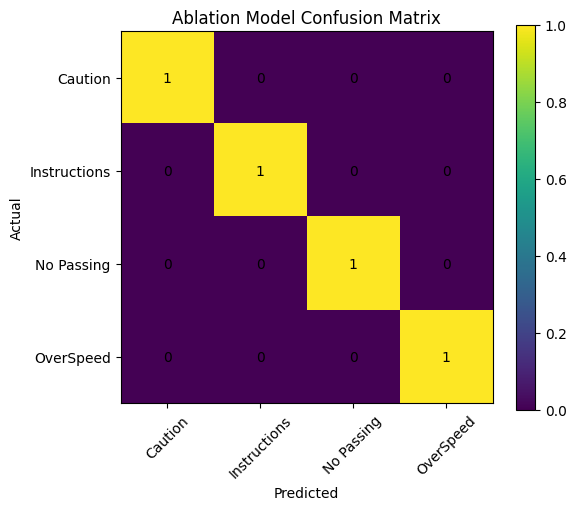

In [94]:
ablation_cm = confusion_matrix(true_classes, ablation_pred_classes)

print("Ablation Confusion Matrix:")
print(ablation_cm)

plt.figure(figsize=(6, 5))
plt.imshow(ablation_cm)
plt.title("Ablation Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(np.arange(len(class_labels)), class_labels, rotation=45)
plt.yticks(np.arange(len(class_labels)), class_labels)

for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        plt.text(j, i, ablation_cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

Ablation Accuracy/Loss Graphs

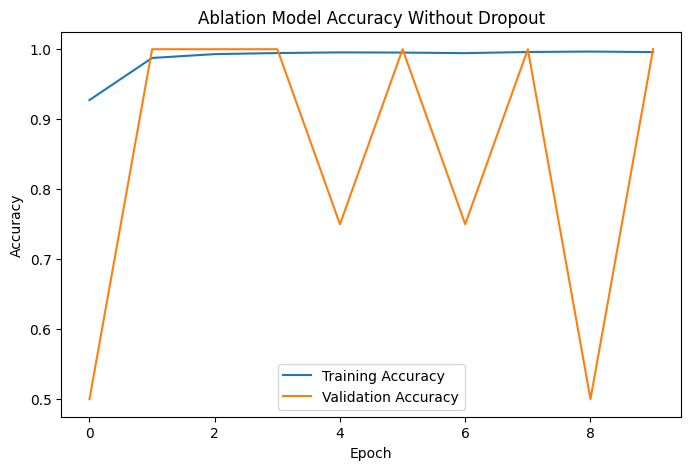

In [72]:
plt.figure(figsize=(8, 5))
plt.plot(history_ablation.history['accuracy'], label='Training Accuracy')
plt.plot(history_ablation.history['val_accuracy'], label='Validation Accuracy')
plt.title('Ablation Model Accuracy Without Dropout')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

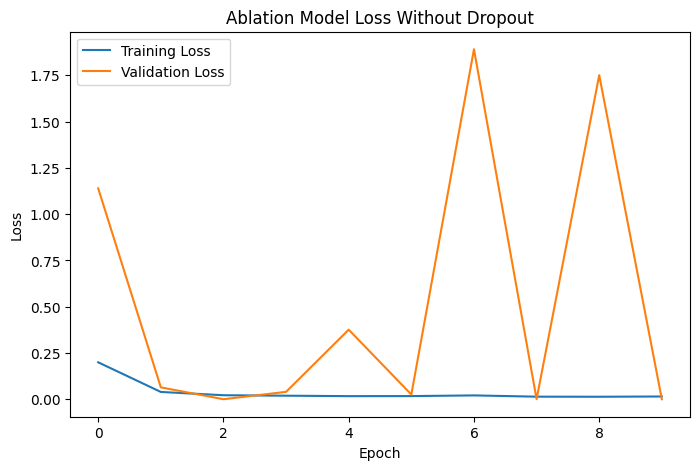

In [73]:
plt.figure(figsize=(8, 5))
plt.plot(history_ablation.history['loss'], label='Training Loss')
plt.plot(history_ablation.history['val_loss'], label='Validation Loss')
plt.title('Ablation Model Loss Without Dropout')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Part B: Transfer Learning with VGG16

Create Transfer Learning Data Generators

In [74]:
transfer_train_generator = train_datagen.flow_from_directory(
    clean_train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

transfer_test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 15878 images belonging to 4 classes.
Found 4 images belonging to 4 classes.


Loading VGG16 Pre-Trained Model

In [77]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

Building Transfer Learning Model

In [76]:
transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

Compile Transfer Model

In [78]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Transfer Model Surgery

In [79]:
transfer_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Training Transfer Model

In [80]:
start_time = time.time()

history_transfer = transfer_model.fit(
    transfer_train_generator,
    epochs=15,
    validation_data=transfer_test_generator
)

transfer_training_time = time.time() - start_time

print("Transfer Model Training Time:", transfer_training_time, "seconds")

Epoch 1/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 276s 517ms/step - accuracy: 0.4505 - loss: 1.2043 - val_accuracy: 0.5000 - val_loss: 1.3018
Epoch 2/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 220s 442ms/step - accuracy: 0.6045 - loss: 0.9809 - val_accuracy: 0.5000 - val_loss: 1.2288
Epoch 3/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 218s 438ms/step - accuracy: 0.6671 - loss: 0.8583 - val_accuracy: 0.5000 - val_loss: 1.2048
Epoch 4/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 223s 448ms/step - accuracy: 0.7074 - loss: 0.7739 - val_accuracy: 0.5000 - val_loss: 1.1295
Epoch 5/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 217s 437ms/step - accuracy: 0.7345 - loss: 0.7116 - val_accuracy: 0.5000 - val_loss: 1.1182
Epoch 6/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 215s 433ms/step - accuracy: 0.7541 - loss: 0.6595 - val_accuracy: 0.5000 - val_loss: 1.1249
Epoch 7/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 261s 430ms/step - accuracy: 0.7760 - loss: 0.6197 - val_accuracy: 0.5000 - val_loss: 1.1118
Epoch 8/15
497/497 ━━━━━━━━━━━━━━━━━━━━ 218s 439ms/step - accuracy: 0.7839 -

Transfer Accuracy Graph

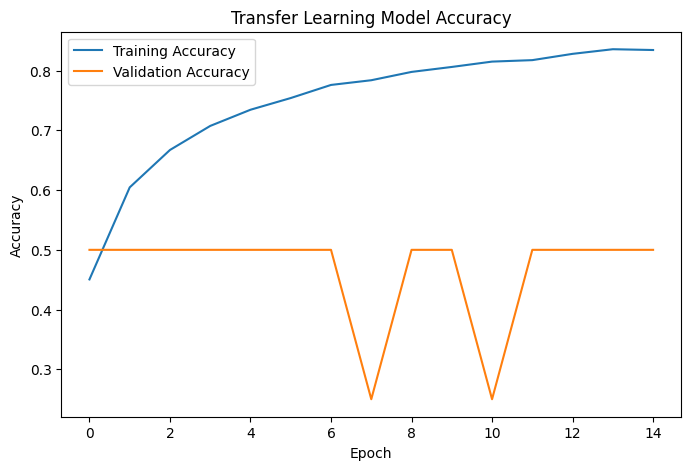

In [82]:
plt.figure(figsize=(8, 5))
plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Transfer Loss Graph

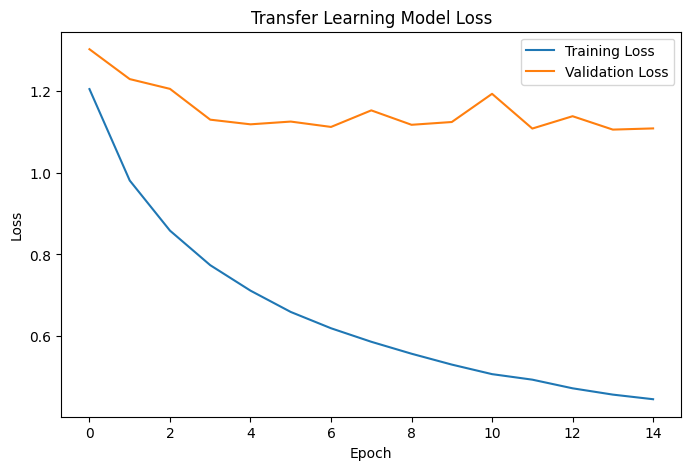

In [83]:
plt.figure(figsize=(8, 5))
plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Evaluate Transfer Model

In [84]:
transfer_loss, transfer_accuracy = transfer_model.evaluate(transfer_test_generator)

print("Transfer Test Loss:", transfer_loss)
print("Transfer Test Accuracy:", transfer_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5000 - loss: 1.1082
Transfer Test Loss: 1.1081820726394653
Transfer Test Accuracy: 0.5


Transfer Precision, Recall, F1-score and Confusion Matrix

In [85]:
transfer_test_generator.reset()

transfer_predictions = transfer_model.predict(transfer_test_generator)
transfer_pred_classes = np.argmax(transfer_predictions, axis=1)

transfer_true_classes = transfer_test_generator.classes
transfer_class_labels = list(transfer_test_generator.class_indices.keys())

transfer_precision = precision_score(transfer_true_classes, transfer_pred_classes, average='weighted', zero_division=0)
transfer_recall = recall_score(transfer_true_classes, transfer_pred_classes, average='weighted', zero_division=0)
transfer_f1 = f1_score(transfer_true_classes, transfer_pred_classes, average='weighted', zero_division=0)

print("Transfer Precision:", transfer_precision)
print("Transfer Recall:", transfer_recall)
print("Transfer F1-score:", transfer_f1)

print("\nTransfer Classification Report:")
print(classification_report(transfer_true_classes, transfer_pred_classes, target_names=transfer_class_labels, zero_division=0))

transfer_cm = confusion_matrix(transfer_true_classes, transfer_pred_classes)

print("Transfer Confusion Matrix:")
print(transfer_cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step
Transfer Precision: 0.375
Transfer Recall: 0.5
Transfer F1-score: 0.41666666666666663

Transfer Classification Report:
              precision    recall  f1-score   support

     Caution       0.00      0.00      0.00         1
Instructions       0.00      0.00      0.00         1
  No Passing       1.00      1.00      1.00         1
   OverSpeed       0.50      1.00      0.67         1

    accuracy                           0.50         4
   macro avg       0.38      0.50      0.42         4
weighted avg       0.38      0.50      0.42         4

Transfer Confusion Matrix:
[[0 0 0 1]
 [1 0 0 0]
 [0 0 1 0]
 [0 0 0 1]]


Transfer Confusion Matrix Graph

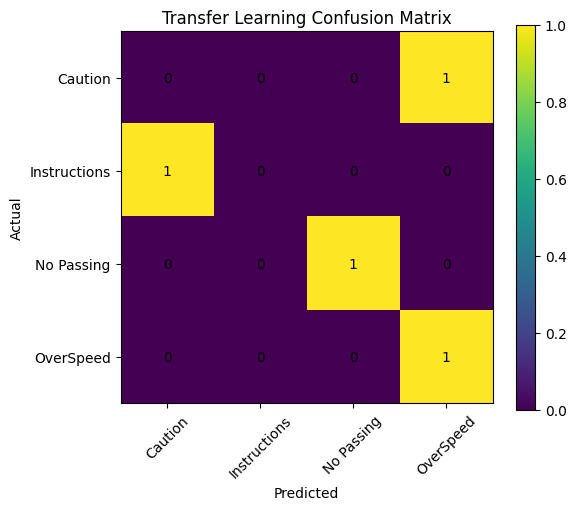

In [86]:
plt.figure(figsize=(6, 5))
plt.imshow(transfer_cm)
plt.title("Transfer Learning Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(np.arange(len(transfer_class_labels)), transfer_class_labels, rotation=45)
plt.yticks(np.arange(len(transfer_class_labels)), transfer_class_labels)

for i in range(len(transfer_class_labels)):
    for j in range(len(transfer_class_labels)):
        plt.text(j, i, transfer_cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

Transfer Learning Prediction Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


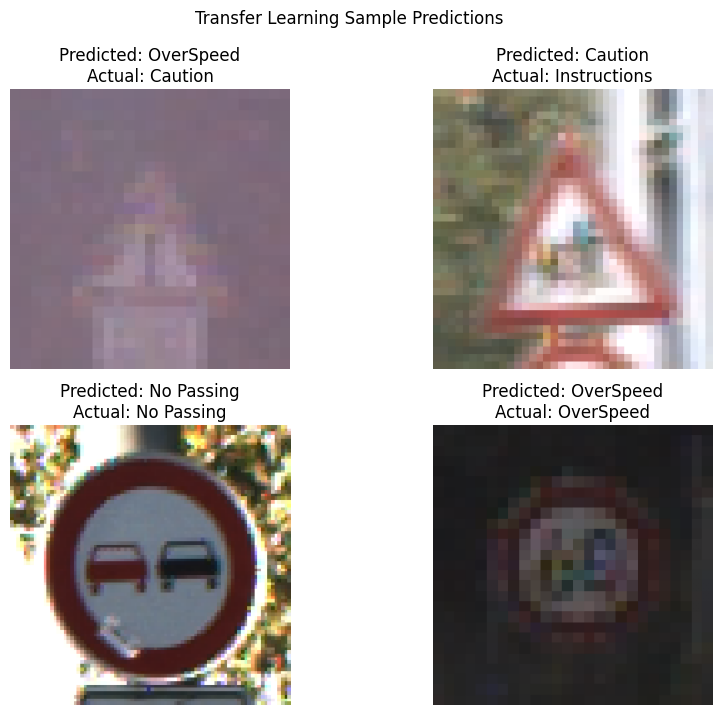

In [96]:
transfer_test_generator.reset()

images, labels = next(transfer_test_generator)

predictions = transfer_model.predict(images)
predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(labels, axis=1)

plt.figure(figsize=(10, 8))

for i in range(len(images)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i])
    plt.title("Predicted: " + transfer_class_labels[predicted_classes[i]] +
              "\nActual: " + transfer_class_labels[actual_classes[i]])
    plt.axis('off')

plt.suptitle("Transfer Learning Sample Predictions")
plt.show()

Fine-Tune Last Few VGG16 Layers

In [87]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

transfer_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_finetune = transfer_model.fit(
    transfer_train_generator,
    epochs=5,
    validation_data=transfer_test_generator
)

finetune_training_time = time.time() - start_time

finetune_loss, finetune_accuracy = transfer_model.evaluate(transfer_test_generator)

print("Fine-tuned Test Loss:", finetune_loss)
print("Fine-tuned Test Accuracy:", finetune_accuracy)
print("Fine-tuning Training Time:", finetune_training_time)

Epoch 1/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 223s 440ms/step - accuracy: 0.8378 - loss: 0.4403 - val_accuracy: 0.5000 - val_loss: 1.0910
Epoch 2/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 218s 439ms/step - accuracy: 0.8454 - loss: 0.4315 - val_accuracy: 0.5000 - val_loss: 1.0889
Epoch 3/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 260s 434ms/step - accuracy: 0.8448 - loss: 0.4332 - val_accuracy: 0.5000 - val_loss: 1.0998
Epoch 4/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 219s 441ms/step - accuracy: 0.8426 - loss: 0.4341 - val_accuracy: 0.5000 - val_loss: 1.0878
Epoch 5/5
497/497 ━━━━━━━━━━━━━━━━━━━━ 216s 435ms/step - accuracy: 0.8463 - loss: 0.4289 - val_accuracy: 0.5000 - val_loss: 1.1032
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5000 - loss: 1.1032
Fine-tuned Test Loss: 1.1031675338745117
Fine-tuned Test Accuracy: 0.5
Fine-tuning Training Time: 1137.075409412384


Fine-Tuning Precision, Recall, F1-score, Confusion Matrix

In [97]:
transfer_test_generator.reset()

finetune_predictions = transfer_model.predict(transfer_test_generator)
finetune_pred_classes = np.argmax(finetune_predictions, axis=1)

finetune_true_classes = transfer_test_generator.classes
finetune_class_labels = list(transfer_test_generator.class_indices.keys())

finetune_precision = precision_score(
    finetune_true_classes,
    finetune_pred_classes,
    average='weighted',
    zero_division=0
)

finetune_recall = recall_score(
    finetune_true_classes,
    finetune_pred_classes,
    average='weighted',
    zero_division=0
)

finetune_f1 = f1_score(
    finetune_true_classes,
    finetune_pred_classes,
    average='weighted',
    zero_division=0
)

print(
    "Fine-tuned Accuracy:", round(finetune_accuracy, 4),
    "| Precision:", round(finetune_precision, 4),
    "| Recall:", round(finetune_recall, 4),
    "| F1-score:", round(finetune_f1, 4)
)

print("\nFine-tuned Classification Report:")
print(classification_report(
    finetune_true_classes,
    finetune_pred_classes,
    target_names=finetune_class_labels,
    zero_division=0
))

finetune_cm = confusion_matrix(finetune_true_classes, finetune_pred_classes)

print("Fine-tuned Confusion Matrix:")
print(finetune_cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Fine-tuned Accuracy: 0.5 | Precision: 0.375 | Recall: 0.5 | F1-score: 0.4167

Fine-tuned Classification Report:
              precision    recall  f1-score   support

     Caution       0.00      0.00      0.00         1
Instructions       0.00      0.00      0.00         1
  No Passing       1.00      1.00      1.00         1
   OverSpeed       0.50      1.00      0.67         1

    accuracy                           0.50         4
   macro avg       0.38      0.50      0.42         4
weighted avg       0.38      0.50      0.42         4

Fine-tuned Confusion Matrix:
[[0 0 0 1]
 [1 0 0 0]
 [0 0 1 0]
 [0 0 0 1]]


Fine-Tuning Confusion Matrix Graph

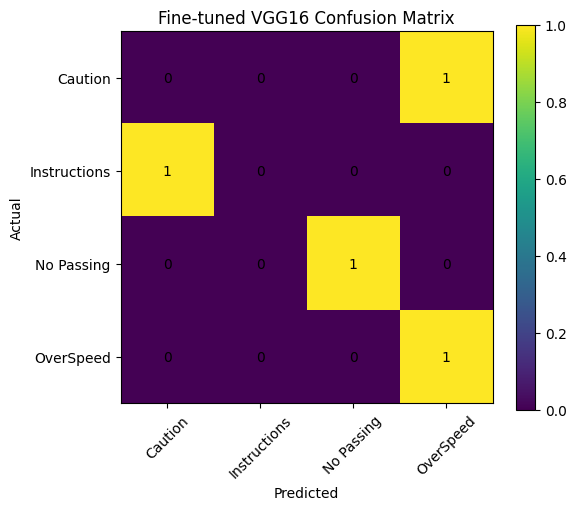

In [98]:
plt.figure(figsize=(6, 5))
plt.imshow(finetune_cm)
plt.title("Fine-tuned VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(np.arange(len(finetune_class_labels)), finetune_class_labels, rotation=45)
plt.yticks(np.arange(len(finetune_class_labels)), finetune_class_labels)

for i in range(len(finetune_class_labels)):
    for j in range(len(finetune_class_labels)):
        plt.text(j, i, finetune_cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

#Final Comparison Section

Final Metrics Table

In [99]:
results = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Deeper CNN Adam",
        "Deeper CNN SGD",
        "Ablation Without Dropout",
        "Transfer Learning VGG16",
        "Fine-tuned VGG16"
    ],
    "Accuracy": [
        baseline_accuracy,
        deeper_accuracy,
        sgd_accuracy,
        ablation_accuracy,
        transfer_accuracy,
        finetune_accuracy
    ],
    "Precision": [
        baseline_precision,
        deeper_precision,
        sgd_precision,
        ablation_precision,
        transfer_precision,
        finetune_precision
    ],
    "Recall": [
        baseline_recall,
        deeper_recall,
        sgd_recall,
        ablation_recall,
        transfer_recall,
        finetune_recall
    ],
    "F1-score": [
        baseline_f1,
        deeper_f1,
        sgd_f1,
        ablation_f1,
        transfer_f1,
        finetune_f1
    ],
    "Training Time (seconds)": [
        baseline_training_time,
        deeper_training_time,
        sgd_training_time,
        ablation_training_time,
        transfer_training_time,
        finetune_training_time
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score,Training Time (seconds)
0,Baseline CNN,1.0,1.000,1.0,1.000000,430.274855
1,Deeper CNN Adam,1.0,1.000,1.0,1.000000,474.571431
2,Deeper CNN SGD,1.0,1.000,1.0,1.000000,498.934690
3,Ablation Without Dropout,1.0,1.000,1.0,1.000000,355.493293
4,Transfer Learning VGG16,0.5,0.375,0.5,0.416667,3447.042081
5,Fine-tuned VGG16,0.5,0.375,0.5,0.416667,1137.075409


Accuracy comparison graph

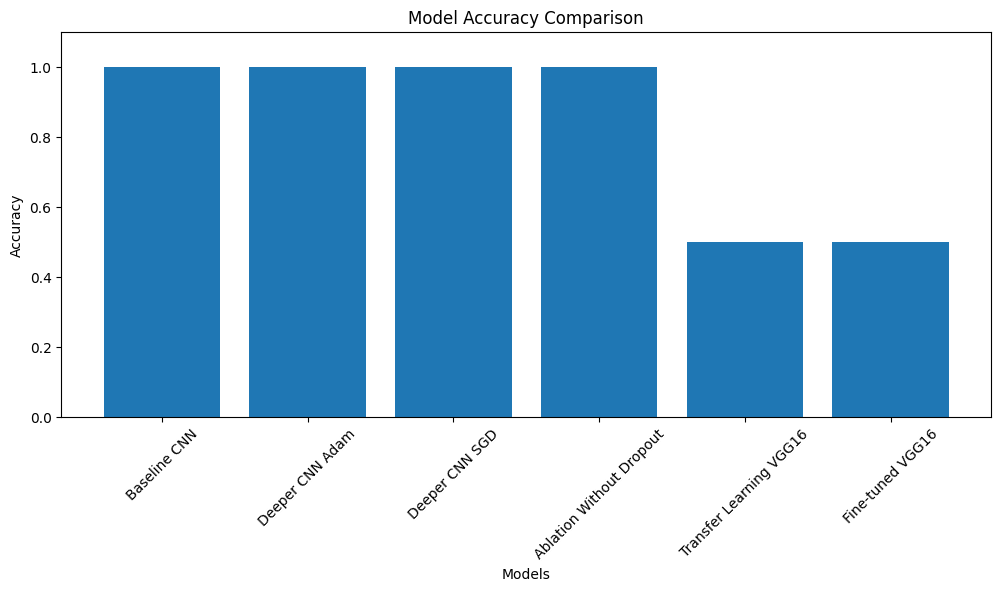

In [89]:
plt.figure(figsize=(12, 5))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1.1)
plt.show()

F1-score Comparison Graph

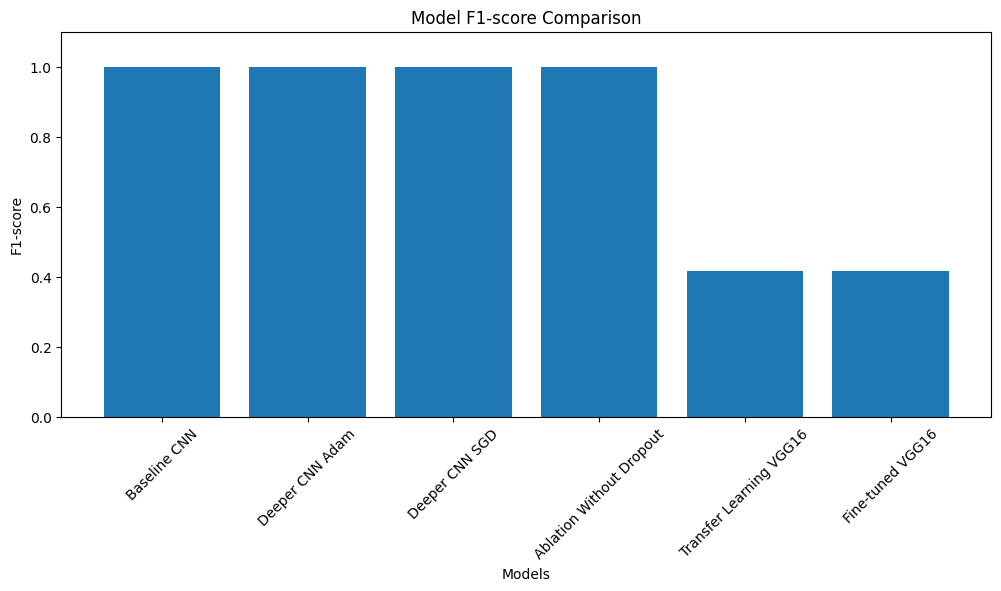

In [90]:
plt.figure(figsize=(12, 5))
plt.bar(results["Model"], results["F1-score"])
plt.title("Model F1-score Comparison")
plt.xlabel("Models")
plt.ylabel("F1-score")
plt.xticks(rotation=45)
plt.ylim(0, 1.1)
plt.show()

Training Time Comparison Graph

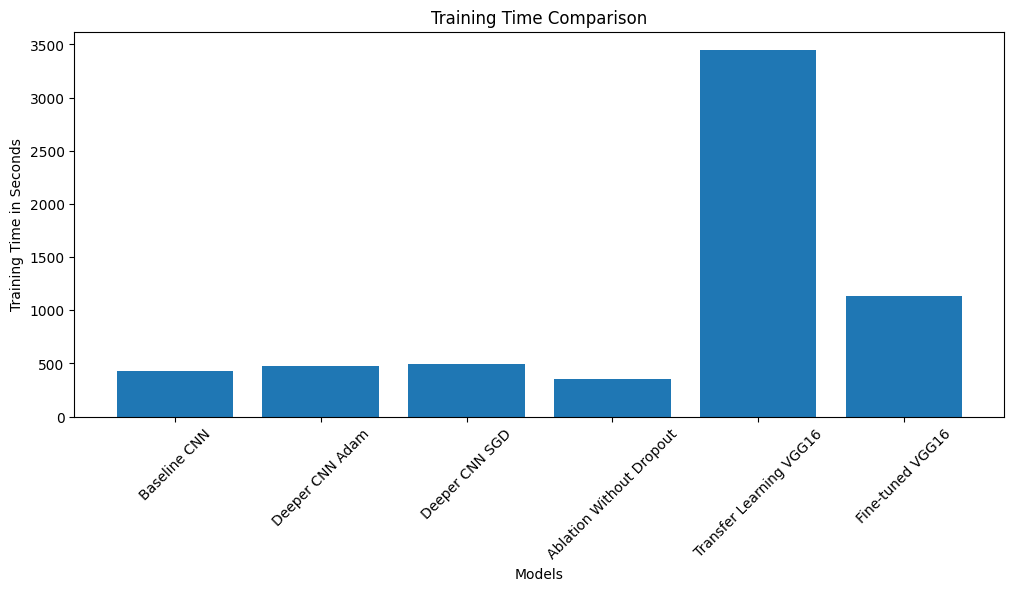

In [91]:
plt.figure(figsize=(12, 5))
plt.bar(results["Model"], results["Training Time (seconds)"])
plt.title("Training Time Comparison")
plt.xlabel("Models")
plt.ylabel("Training Time in Seconds")
plt.xticks(rotation=45)
plt.show()